### Nanocomp - 2025.02 - Prof. Omar
---
<p> 
Optimizing quantum wells for quantum bragg mirror detectors via genetic algorithms(NSGA-II).
</p>

- Guilherme Rigacci
- Marco Túlio Mata
- Lucas Gabriel

---

#### 1. _AUTOMATED RUN_

In [ ]:
%%capture

import include.run_prog as prog

ex1 = [4, 2e-9, 7e-9, 5e-9, 1, 2e-9, 7e-9]
param = ex1
if(len(param) != 7):
    raise ValueError("Parameter list must have exactly 7 elements.")
out_dir = prog.run_qbmd(param[0], param[1], param[2], param[3], param[4], param[5], param[6], create_param_folder=True)
print("Outputs in:", out_dir)

#### 2. _VISUALIZATION_

In [ ]:
import include.visualize as viz
out_dir = "/home/mark/nano.compQBMD/linux_executable/manual_runs/05x2.0_7.0__2.0__01x2.0_7.0/"
res = viz.visualize_all(out_dir, show=True)

### 3. _GENETIC ALGORITHM_

In [ ]:
import sys
from include.run_opt import run_optimization as run_ga

if __name__ == "__main__":
    try:
        print("Iniciando otimização GA multi-objetivo...")
        
        # Example for stating point
        # initial_population_csv="../linux_executable/optimization_results/pareto_full_guilherme4320.csv"
        initial_population_csv="../linux_executable/optimization_results/pareto_full_bestInPaper.csv"
        
        # You may want to clear any intermediate_sim_*.csv before running
        # results = run_ga() 
        results = run_ga(initial_population_csv)
        
        print("\n Otimização concluída com sucesso!")
        sys.exit(0)
    except KeyboardInterrupt:
        print("\n  Otimização interrompida pelo usuário")
        sys.exit(1)
    except Exception as e:
        print(f"\n:c Error durante a otimização: {e}")
        import traceback
        traceback.print_exc()
        sys.exit(1)


### 4. _PARETO_ _FRONTS_

In [1]:
# Load Pareto front results using pareto_extract module
from include.pareto_extract import load_pareto_results, display_best_solutions, visualize_pareto_2d, visualize_pareto_3d, get_statistics

# Load the most recent optimization results
try:
    df = load_pareto_results()
    # df = load_pareto_results("../../linux_executable/optimization_results/intermediate_sim_0233.csv")
    print("\nColumns:", list(df.columns))
    print("\nFirst 5 solutions:")
    display(df.head())
except FileNotFoundError as e:
    print(e)
    df = None

Loaded 271 Pareto-optimal solutions from /home/mark/nano.compQBMD/linux_executable/optimization_results/pareto_full_sim232.csv

Columns: ['RW', 'RQWt', 'RQBt', 'MQWt', 'LW', 'LQWt', 'LQBt', 'max_energy_eV', 'max_photocurrent', 'quality_factor', 'prominence']

First 5 solutions:


,RW,RQWt,RQBt,MQWt,LW,LQWt,LQBt,max_energy_eV,max_photocurrent,quality_factor,prominence
0,5,2.051,7.032,2.637,1,2.051,7.032,314.300020,1.514062e-11,224.5,0.231115
1,7,2.344,5.860,3.223,3,1.465,7.032,336.400021,5.421058e-12,0.0,9.606039
2,7,1.758,8.790,2.637,3,1.465,9.376,300.800019,5.119447e-10,0.0,180.007773
3,7,2.051,7.032,2.637,6,1.758,7.911,428.100027,3.260799e-10,0.0,0.000000
4,4,9.669,7.618,6.446,2,2.344,1.465,463.400029,5.405665e-13,926.8,0.000172


In [2]:
# Display summary statistics
if df is not None:
    stats = get_statistics(df)
    display(stats)

,objective,min,max,mean,std
0,Energia do Pico (eV),0.0,4.999000e+02,3.513367e+02,1.795959e+02
1,Intensidade da Fotocorrente,0.0,8.673201e-07,1.814289e-08,8.399381e-08
2,Fator de Qualidade,0.0,4.956000e+03,5.825042e+02,1.003394e+03
3,Proeminência,0.0,1.800078e+02,6.162800e+00,2.301499e+01


In [3]:
# Display best solutions for each objective
if df is not None:
    display_best_solutions(df)


MELHORES SOLUÇÕES POR OBJETIVO

Melhor Energia do Pico (eV):
   Valor: 499.900031
   Parâmetros: RW=7.0, RQWt=7.910999999999999, RQBt=6.153, MQWt=7.910999999999999, LW=5.0, LQWt=5.566999999999999, LQBt=4.981
   Outros objetivos:
     - Intensidade da Fotocorrente: 0.000000
     - Fator de Qualidade: 75.742424
     - Proeminência: 0.427148

Melhor Intensidade da Fotocorrente:
   Valor: 0.000001
   Parâmetros: RW=9.0, RQWt=2.757666, RQBt=14.139684, MQWt=2.772054, LW=7.0, LQWt=1.011923, LQBt=13.790326
   Outros objetivos:
     - Energia do Pico (eV): 9.379727
     - Fator de Qualidade: 616.554139
     - Proeminência: 1.000000

Melhor Fator de Qualidade:
   Valor: 4956.000000
   Parâmetros: RW=5.0, RQWt=1.4432934216901998, RQBt=6.173861069239728, MQWt=1.621697758301538, LW=4.0, LQWt=9.854092615062545, LQBt=9.28678518589716
   Outros objetivos:
     - Energia do Pico (eV): 495.600031
     - Intensidade da Fotocorrente: 0.000000
     - Proeminência: 14.312786

Melhor Proeminência:
   Valor:

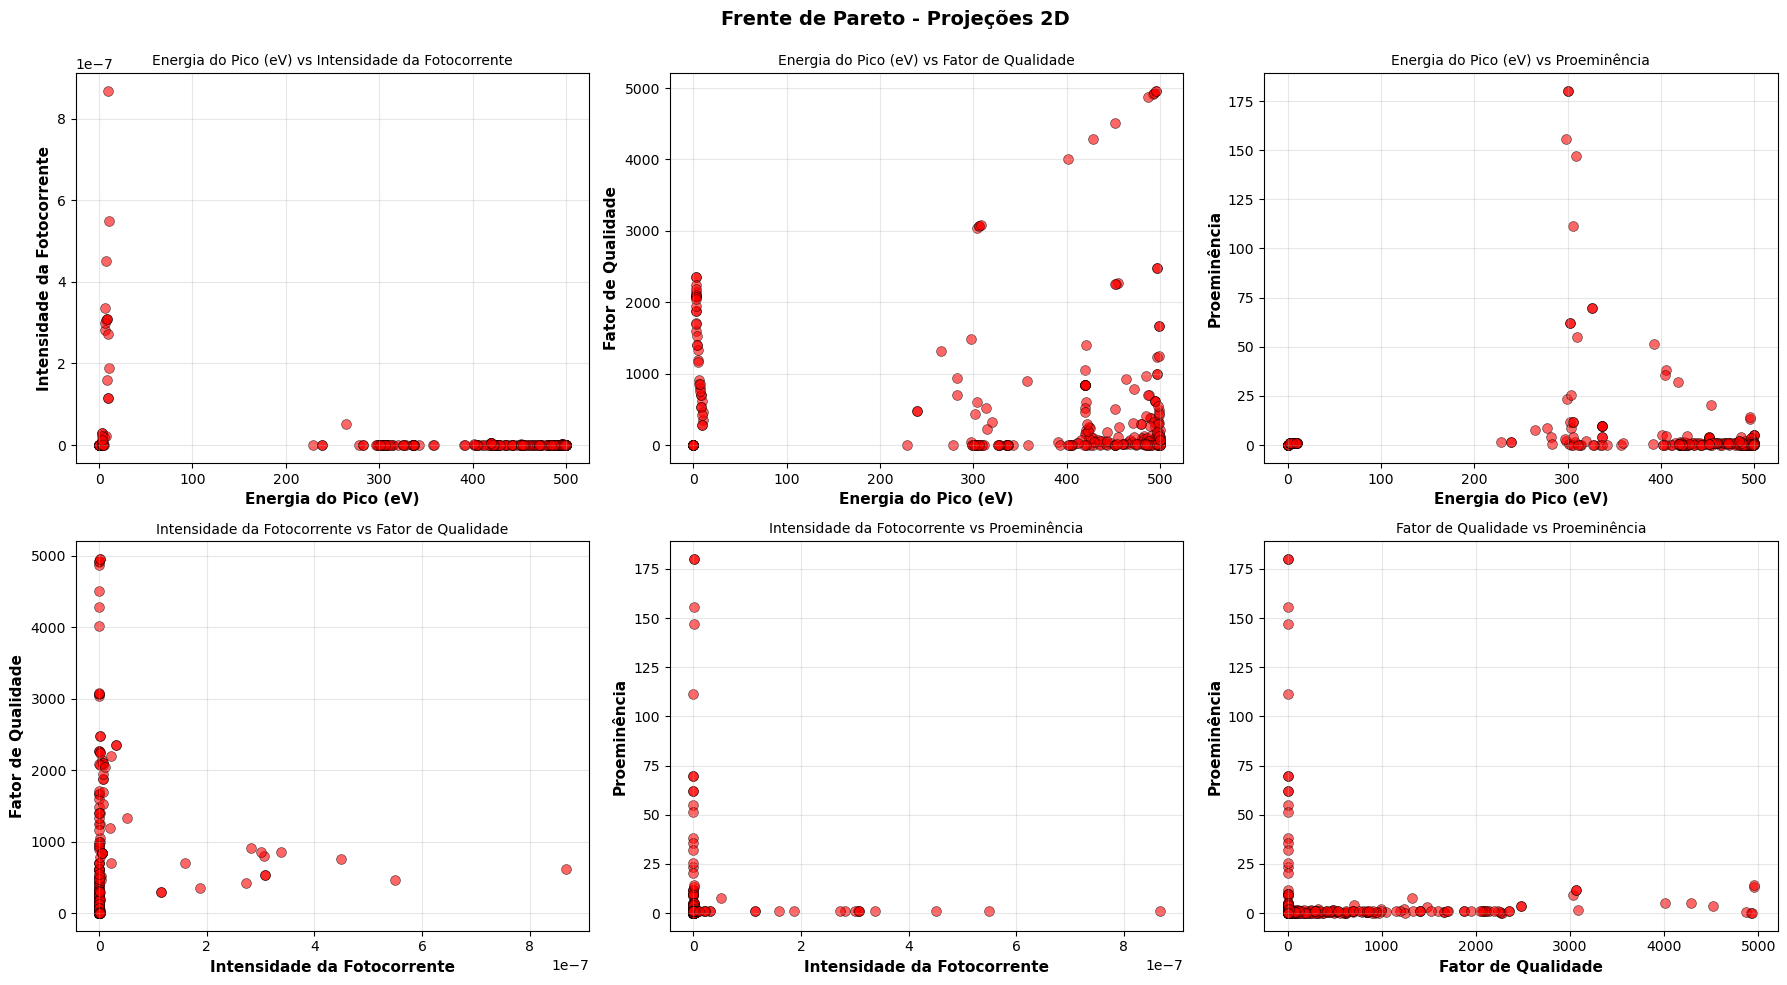

In [4]:
# projections
if df is not None:
    visualize_pareto_2d(df, show=True, save=False)

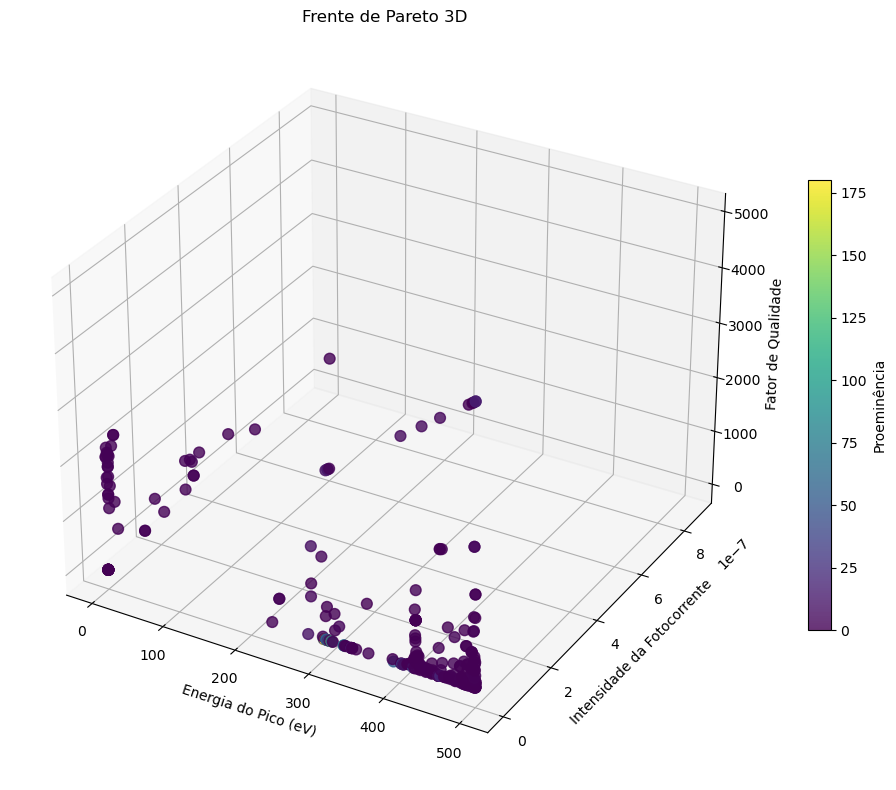

In [8]:
# representing 4 goals
if df is not None:
    visualize_pareto_3d(df, show=True, save=False)

### 5. _CONCLUSIONS_ - Parameter-Objective Relationships

In [9]:
# Analyze relationships between input parameters and objectives
from include.pareto_extract import analyze_parameter_objective_relationships, print_parameter_analysis, get_conclusions_markdown

if df is not None:
    # Perform analysis on Pareto front data
    analysis = analyze_parameter_objective_relationships(df, top_percent=25)
    
    # Print detailed analysis
    print_parameter_analysis(analysis)


ANÁLISE DE RELAÇÕES PARÂMETROS-OBJETIVOS

────────────────────────────────────────────────────────────────────────────────
GOAL: Energia do Pico (eV)
   (Análise dos top 67 indivíduos)
────────────────────────────────────────────────────────────────────────────────

Parâmetro  │          Global           │      Top Performers       │   Corr  
           │   Min      Max      Mean   │   Min      Max      Mean   │         
───────────┼───────────────────────────┼───────────────────────────┼─────────
RW         │     1.00     9.00     6.37 │     1.00     9.00     5.97 │ -0.435 
RQWt       │     1.05     9.83     3.65 │     1.21     9.08     4.91 │  0.197 
RQBt       │     1.01    14.94     7.55 │     1.11     8.99     5.88 │ -0.641 ↓
MQWt       │     1.14     9.62     4.24 │     1.17     8.20     5.72 │  0.237 
LW         │     1.00     9.00     3.87 │     1.00     8.00     3.91 │ -0.356 
LQWt       │     1.00     9.94     4.23 │     1.45     9.94     5.79 │  0.304 
LQBt       │     1.42

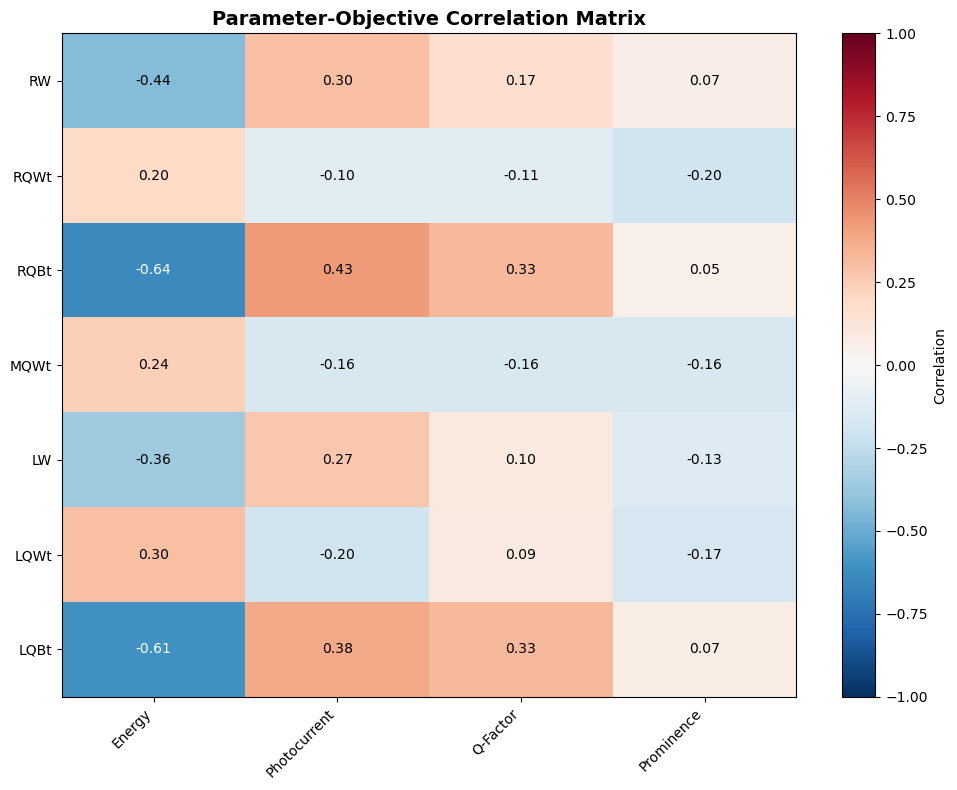

In [10]:
# visualize correlacoes parametro-objetivo
import matplotlib.pyplot as plt
import numpy as np

if df is not None:
    param_cols = ['RW', 'RQWt', 'RQBt', 'MQWt', 'LW', 'LQWt', 'LQBt']
    obj_cols = ['max_energy_eV', 'max_photocurrent', 'quality_factor', 'prominence']
    
    # Calculate correlation matrix
    all_cols = param_cols + obj_cols
    corr_matrix = df[all_cols].corr()
    
    # Extract only parameter-objective correlations
    param_obj_corr = corr_matrix.loc[param_cols, obj_cols]
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(param_obj_corr.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    
    # Labels
    ax.set_xticks(range(len(obj_cols)))
    ax.set_xticklabels(['Energy', 'Photocurrent', 'Q-Factor', 'Prominence'], rotation=45, ha='right')
    ax.set_yticks(range(len(param_cols)))
    ax.set_yticklabels(param_cols)
    
    # Add correlation values as text
    for i in range(len(param_cols)):
        for j in range(len(obj_cols)):
            val = param_obj_corr.iloc[i, j]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=10)
    
    plt.colorbar(im, label='Correlation')
    plt.title('Parameter-Objective Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### AI ANALYZE

In [11]:
from IPython.display import Markdown, display

if df is not None:
    conclusions_md = get_conclusions_markdown(analysis)
    display(Markdown(conclusions_md))

## 📋 Conclusões da Análise do Pareto Front
### Relações entre Parâmetros de Entrada e Objetivos

#### Energia do Pico (eV)
Análise baseada nos top 67 indivíduos do Pareto front.
**Correlações positivas (valores maiores ajudam):**
- `LQWt`: correlação = 0.304

**Correlações negativas (valores menores ajudam):**
- `RQBt`: correlação = -0.641
- `LQBt`: correlação = -0.605
- `RW`: correlação = -0.435
- `LW`: correlação = -0.356

#### Intensidade da Fotocorrente
Análise baseada nos top 67 indivíduos do Pareto front.
**Correlações positivas (valores maiores ajudam):**
- `RQBt`: correlação = 0.429
- `LQBt`: correlação = 0.376
- `RW`: correlação = 0.303

#### Fator de Qualidade
Análise baseada nos top 67 indivíduos do Pareto front.
**Correlações positivas (valores maiores ajudam):**
- `LQBt`: correlação = 0.327
- `RQBt`: correlação = 0.326

#### Proeminência
Análise baseada nos top 67 indivíduos do Pareto front.

**Faixas de valores preferidas nos melhores indivíduos:**
- `LQBt`: [5.67, 9.92]

---
*Nota: Correlações acima de |0.3| são consideradas relevantes. Faixas preferidas indicam parâmetros onde os melhores indivíduos convergem.*
